**XAI (Machine Learning explicable) para casos de uso con texto**

En este cuaderno se busca entender cuáles son las razones que hacen que una persona recomiende o no un juego en Steam de acuerdo a su review.

Para ello se entrenarán modelos de clasificación de reviews y luego se emplearán técnicas de explicabilidad de modelos para entender por qué toman las decisiones.

## Importar librerías

In [3]:
!pip install langdetect

In [4]:

from langdetect import detect
from wordcloud import WordCloud

import shap

import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer


nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Carga de datos

In [5]:
df = pd.read_csv("gtav_english.csv")
df

,Player nick name,Title,Date,Hours,PlayerURL,Comments
0,Avocado,Not Recommended,April 22,"1,413.4",https://steamcommunity.com/profiles/7656119797...,"Firstly, I've been with steam now for 13 years..."
1,armin,Not Recommended,March 23,878.4,https://steamcommunity.com/profiles/7656119880...,BEST ANTI CHEAT SYSTEM EVER :D ban legit playe...
2,Blue Shaymin,Not Recommended,June 29,377.6,https://steamcommunity.com/id/bluestorm46/,I login to GTA online after not having played ...
3,RudeMoose,Not Recommended,"June 24, 2017",868.5,https://steamcommunity.com/profiles/7656119802...,GTA V pre purchase $69.99Megalodon Shark card ...
4,ABG,Not Recommended,August 1,631.2,https://steamcommunity.com/id/afbg123/,Rockstar can ban suspend/ban your account and ...
...,...,...,...,...,...,...
73334,cookieman,Not Recommended,"June 18, 2017",75.3,https://steamcommunity.com/id/Ugandancookieman/,No support for mods anymore. ♥♥♥♥ you Take Two
73335,Steve Arnott,Not Recommended,"June 20, 2017",299.3,https://steamcommunity.com/id/146436413514/,"♥♥♥♥ GTA 5, was an awesome game a little while..."
73336,Uncle Tomer,Not Recommended,"June 18, 2017",222.8,https://steamcommunity.com/id/0b11/,Open IV is down and it suks!!!!don't buy this ...
73337,henry___chan,Not Recommended,"June 18, 2017",403.4,https://steamcommunity.com/profiles/7656119820...,Bring back OpenIV


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73339 entries, 0 to 73338
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Player nick name  73335 non-null  object
 1   Title             73339 non-null  object
 2   Date              73339 non-null  object
 3   Hours             73339 non-null  object
 4   PlayerURL         73339 non-null  object
 5   Comments          73323 non-null  object
dtypes: object(6)
memory usage: 3.4+ MB


In [7]:
df = df.dropna()
df

,Player nick name,Title,Date,Hours,PlayerURL,Comments
0,Avocado,Not Recommended,April 22,"1,413.4",https://steamcommunity.com/profiles/7656119797...,"Firstly, I've been with steam now for 13 years..."
1,armin,Not Recommended,March 23,878.4,https://steamcommunity.com/profiles/7656119880...,BEST ANTI CHEAT SYSTEM EVER :D ban legit playe...
2,Blue Shaymin,Not Recommended,June 29,377.6,https://steamcommunity.com/id/bluestorm46/,I login to GTA online after not having played ...
3,RudeMoose,Not Recommended,"June 24, 2017",868.5,https://steamcommunity.com/profiles/7656119802...,GTA V pre purchase $69.99Megalodon Shark card ...
4,ABG,Not Recommended,August 1,631.2,https://steamcommunity.com/id/afbg123/,Rockstar can ban suspend/ban your account and ...
...,...,...,...,...,...,...
73334,cookieman,Not Recommended,"June 18, 2017",75.3,https://steamcommunity.com/id/Ugandancookieman/,No support for mods anymore. ♥♥♥♥ you Take Two
73335,Steve Arnott,Not Recommended,"June 20, 2017",299.3,https://steamcommunity.com/id/146436413514/,"♥♥♥♥ GTA 5, was an awesome game a little while..."
73336,Uncle Tomer,Not Recommended,"June 18, 2017",222.8,https://steamcommunity.com/id/0b11/,Open IV is down and it suks!!!!don't buy this ...
73337,henry___chan,Not Recommended,"June 18, 2017",403.4,https://steamcommunity.com/profiles/7656119820...,Bring back OpenIV


### Balanceo de target

In [8]:
df["Title"].value_counts()

,count
Title,
Not Recommended,43222
Recommended,30097


In [9]:
# Undersampling
min_size_of_target_class = df["Title"].value_counts().min()

df = pd.concat([
    df[df["Title"] == target].sample(min_size_of_target_class) for target in df["Title"].unique()
])

df

,Player nick name,Title,Date,Hours,PlayerURL,Comments
20576,tashkavarish,Not Recommended,"April 19, 2016","2,215.5",https://steamcommunity.com/id/tashkavarish/,hardware killing graphics +1 pointstory worth ...
25163,Viddy,Not Recommended,"June 15, 2017",106.7,https://steamcommunity.com/profiles/7656119802...,"Unfortunately, single player mods have been ru..."
18038,Forlorn Weylin,Not Recommended,"January 7, 2017",355.6,https://steamcommunity.com/profiles/7656119810...,After a short period of time the game gets ver...
35881,Darky,Not Recommended,"November 1, 2017","1,568.4",https://steamcommunity.com/id/xx_RedPlayer_xx/,Don't buy if you live in Asia region. Most of ...
1463,Hammer of Justice,Not Recommended,"August 9, 2016",150.1,https://steamcommunity.com/profiles/7656119806...,-online is filled with hackers-rockstar does n...
...,...,...,...,...,...,...
68884,Yozora No Ryuu,Recommended,"April 13, 2015",25.8,https://steamcommunity.com/id/reaperlord3/,Couldn't wait for this to come on and now that...
5608,Amxzy,Recommended,"November 23, 2016",65.1,https://steamcommunity.com/id/amxzy/,I've had the pleasure of experiencing Grand Th...
27737,Diggerrmon,Recommended,"April 13, 2016",267.7,https://steamcommunity.com/id/Diggerrmon/,hell yea if u don't like gta 5 then why are u ...
67202,SeeoZ,Recommended,"December 29, 2016",100.7,https://steamcommunity.com/id/iasda9sg9as9das/,"This game is very, very good.... BUT the amoun..."


## Preprocessing

In [10]:
df["prompt_length"] = df["Comments"].apply(lambda x: len(x))
df

,Player nick name,Title,Date,Hours,PlayerURL,Comments,prompt_length
20576,tashkavarish,Not Recommended,"April 19, 2016","2,215.5",https://steamcommunity.com/id/tashkavarish/,hardware killing graphics +1 pointstory worth ...,566
25163,Viddy,Not Recommended,"June 15, 2017",106.7,https://steamcommunity.com/profiles/7656119802...,"Unfortunately, single player mods have been ru...",388
18038,Forlorn Weylin,Not Recommended,"January 7, 2017",355.6,https://steamcommunity.com/profiles/7656119810...,After a short period of time the game gets ver...,325
35881,Darky,Not Recommended,"November 1, 2017","1,568.4",https://steamcommunity.com/id/xx_RedPlayer_xx/,Don't buy if you live in Asia region. Most of ...,690
1463,Hammer of Justice,Not Recommended,"August 9, 2016",150.1,https://steamcommunity.com/profiles/7656119806...,-online is filled with hackers-rockstar does n...,229
...,...,...,...,...,...,...,...
68884,Yozora No Ryuu,Recommended,"April 13, 2015",25.8,https://steamcommunity.com/id/reaperlord3/,Couldn't wait for this to come on and now that...,560
5608,Amxzy,Recommended,"November 23, 2016",65.1,https://steamcommunity.com/id/amxzy/,I've had the pleasure of experiencing Grand Th...,359
27737,Diggerrmon,Recommended,"April 13, 2016",267.7,https://steamcommunity.com/id/Diggerrmon/,hell yea if u don't like gta 5 then why are u ...,50
67202,SeeoZ,Recommended,"December 29, 2016",100.7,https://steamcommunity.com/id/iasda9sg9as9das/,"This game is very, very good.... BUT the amoun...",429


In [11]:
df = df[(df["prompt_length"] < 1000) & (df["prompt_length"] > 20)]
df

,Player nick name,Title,Date,Hours,PlayerURL,Comments,prompt_length
20576,tashkavarish,Not Recommended,"April 19, 2016","2,215.5",https://steamcommunity.com/id/tashkavarish/,hardware killing graphics +1 pointstory worth ...,566
25163,Viddy,Not Recommended,"June 15, 2017",106.7,https://steamcommunity.com/profiles/7656119802...,"Unfortunately, single player mods have been ru...",388
18038,Forlorn Weylin,Not Recommended,"January 7, 2017",355.6,https://steamcommunity.com/profiles/7656119810...,After a short period of time the game gets ver...,325
35881,Darky,Not Recommended,"November 1, 2017","1,568.4",https://steamcommunity.com/id/xx_RedPlayer_xx/,Don't buy if you live in Asia region. Most of ...,690
1463,Hammer of Justice,Not Recommended,"August 9, 2016",150.1,https://steamcommunity.com/profiles/7656119806...,-online is filled with hackers-rockstar does n...,229
...,...,...,...,...,...,...,...
68884,Yozora No Ryuu,Recommended,"April 13, 2015",25.8,https://steamcommunity.com/id/reaperlord3/,Couldn't wait for this to come on and now that...,560
5608,Amxzy,Recommended,"November 23, 2016",65.1,https://steamcommunity.com/id/amxzy/,I've had the pleasure of experiencing Grand Th...,359
27737,Diggerrmon,Recommended,"April 13, 2016",267.7,https://steamcommunity.com/id/Diggerrmon/,hell yea if u don't like gta 5 then why are u ...,50
67202,SeeoZ,Recommended,"December 29, 2016",100.7,https://steamcommunity.com/id/iasda9sg9as9das/,"This game is very, very good.... BUT the amoun...",429


In [12]:
def detect_language(text):
    try:
        return detect(text)
    except:
        return None

df["language"] = df["Comments"].apply(lambda x: detect_language(x))
df

/tmp/ipython-input-3085669529.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["language"] = df["Comments"].apply(lambda x: detect_language(x))


,Player nick name,Title,Date,Hours,PlayerURL,Comments,prompt_length,language
20576,tashkavarish,Not Recommended,"April 19, 2016","2,215.5",https://steamcommunity.com/id/tashkavarish/,hardware killing graphics +1 pointstory worth ...,566,en
25163,Viddy,Not Recommended,"June 15, 2017",106.7,https://steamcommunity.com/profiles/7656119802...,"Unfortunately, single player mods have been ru...",388,en
18038,Forlorn Weylin,Not Recommended,"January 7, 2017",355.6,https://steamcommunity.com/profiles/7656119810...,After a short period of time the game gets ver...,325,en
35881,Darky,Not Recommended,"November 1, 2017","1,568.4",https://steamcommunity.com/id/xx_RedPlayer_xx/,Don't buy if you live in Asia region. Most of ...,690,en
1463,Hammer of Justice,Not Recommended,"August 9, 2016",150.1,https://steamcommunity.com/profiles/7656119806...,-online is filled with hackers-rockstar does n...,229,en
...,...,...,...,...,...,...,...,...
68884,Yozora No Ryuu,Recommended,"April 13, 2015",25.8,https://steamcommunity.com/id/reaperlord3/,Couldn't wait for this to come on and now that...,560,en
5608,Amxzy,Recommended,"November 23, 2016",65.1,https://steamcommunity.com/id/amxzy/,I've had the pleasure of experiencing Grand Th...,359,en
27737,Diggerrmon,Recommended,"April 13, 2016",267.7,https://steamcommunity.com/id/Diggerrmon/,hell yea if u don't like gta 5 then why are u ...,50,en
67202,SeeoZ,Recommended,"December 29, 2016",100.7,https://steamcommunity.com/id/iasda9sg9as9das/,"This game is very, very good.... BUT the amoun...",429,en


In [13]:
df = df[df["language"] == "en"]
df

,Player nick name,Title,Date,Hours,PlayerURL,Comments,prompt_length,language
20576,tashkavarish,Not Recommended,"April 19, 2016","2,215.5",https://steamcommunity.com/id/tashkavarish/,hardware killing graphics +1 pointstory worth ...,566,en
25163,Viddy,Not Recommended,"June 15, 2017",106.7,https://steamcommunity.com/profiles/7656119802...,"Unfortunately, single player mods have been ru...",388,en
18038,Forlorn Weylin,Not Recommended,"January 7, 2017",355.6,https://steamcommunity.com/profiles/7656119810...,After a short period of time the game gets ver...,325,en
35881,Darky,Not Recommended,"November 1, 2017","1,568.4",https://steamcommunity.com/id/xx_RedPlayer_xx/,Don't buy if you live in Asia region. Most of ...,690,en
1463,Hammer of Justice,Not Recommended,"August 9, 2016",150.1,https://steamcommunity.com/profiles/7656119806...,-online is filled with hackers-rockstar does n...,229,en
...,...,...,...,...,...,...,...,...
68884,Yozora No Ryuu,Recommended,"April 13, 2015",25.8,https://steamcommunity.com/id/reaperlord3/,Couldn't wait for this to come on and now that...,560,en
5608,Amxzy,Recommended,"November 23, 2016",65.1,https://steamcommunity.com/id/amxzy/,I've had the pleasure of experiencing Grand Th...,359,en
27737,Diggerrmon,Recommended,"April 13, 2016",267.7,https://steamcommunity.com/id/Diggerrmon/,hell yea if u don't like gta 5 then why are u ...,50,en
67202,SeeoZ,Recommended,"December 29, 2016",100.7,https://steamcommunity.com/id/iasda9sg9as9das/,"This game is very, very good.... BUT the amoun...",429,en


In [14]:
simplifier = PorterStemmer()

In [15]:
def get_tokens(review, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if not token.isalpha(): continue
    if token in ENGLISH_STOP_WORDS: continue
    token = token.lower()
    if simplifier_func: token = simplifier_func(token)
    cleaned_tokens.append(token)

  return " ".join(cleaned_tokens)

In [16]:
df["Token String"] = df["Comments"].apply(lambda x: get_tokens(x, simplifier.stem))
df

/tmp/ipython-input-4130639367.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Token String"] = df["Comments"].apply(lambda x: get_tokens(x, simplifier.stem))


,Player nick name,Title,Date,Hours,PlayerURL,Comments,prompt_length,language,Token String
20576,tashkavarish,Not Recommended,"April 19, 2016","2,215.5",https://steamcommunity.com/id/tashkavarish/,hardware killing graphics +1 pointstory worth ...,566,en,hardwar kill graphic pointstori worth damn poi...
25163,Viddy,Not Recommended,"June 15, 2017",106.7,https://steamcommunity.com/profiles/7656119802...,"Unfortunately, single player mods have been ru...",388,en,unfortun singl player mod ruin byt game develo...
18038,Forlorn Weylin,Not Recommended,"January 7, 2017",355.6,https://steamcommunity.com/profiles/7656119810...,After a short period of time the game gets ver...,325,en,after short period time game get stale there l...
35881,Darky,Not Recommended,"November 1, 2017","1,568.4",https://steamcommunity.com/id/xx_RedPlayer_xx/,Don't buy if you live in Asia region. Most of ...,690,en,do buy live asia region most chines player che...
1463,Hammer of Justice,Not Recommended,"August 9, 2016",150.1,https://steamcommunity.com/profiles/7656119806...,-online is filled with hackers-rockstar does n...,229,en,fill doe game legit ban ban againdo buy game o...
...,...,...,...,...,...,...,...,...,...
68884,Yozora No Ryuu,Recommended,"April 13, 2015",25.8,https://steamcommunity.com/id/reaperlord3/,Couldn't wait for this to come on and now that...,560,en,could wait come i say worth game max set bliss...
5608,Amxzy,Recommended,"November 23, 2016",65.1,https://steamcommunity.com/id/amxzy/,I've had the pleasure of experiencing Grand Th...,359,en,i pleasur experienc grand theft auto v day pla...
27737,Diggerrmon,Recommended,"April 13, 2016",267.7,https://steamcommunity.com/id/Diggerrmon/,hell yea if u don't like gta 5 then why are u ...,50,en,hell yea u like gta u
67202,SeeoZ,Recommended,"December 29, 2016",100.7,https://steamcommunity.com/id/iasda9sg9as9das/,"This game is very, very good.... BUT the amoun...",429,en,thi game good but hacker doe repetitv fun game...


## Vectorización

In [17]:
vectorizer = TfidfVectorizer(lowercase=True, max_features=1000, ngram_range=(1,2))
vectorizer.fit(df["Token String"])

TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

In [18]:
X = pd.DataFrame(
    vectorizer.transform(df["Token String"]).toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df.index
)
X

,abil,abl,abl play,absolut,access,account,act,action,activ,actual,...,wtf,xbox,xd,ye,yeah,year,year ago,year old,you,your
20576,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
25163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
18038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
35881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.14079,0.0,0.0,0.0,0.0,0.0
1463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
5608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
27737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
67202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0


## Entrenamiento

In [19]:
y = df["Title"]
y

,Title
20576,Not Recommended
25163,Not Recommended
18038,Not Recommended
35881,Not Recommended
1463,Not Recommended
...,...
68884,Recommended
5608,Recommended
27737,Recommended
67202,Recommended


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                       random_state=42)

##Validación

In [44]:
result = pd.concat([
    y_test.rename("real"),
    pd.Series(model.predict(X_test), index=y_test.index, name="predicted")
], axis=1)
result

,real,predicted
57230,Recommended,Recommended
55401,Recommended,Not Recommended
47802,Recommended,Not Recommended
15425,Not Recommended,Not Recommended
17271,Not Recommended,Not Recommended
...,...,...
43543,Recommended,Recommended
18894,Not Recommended,Recommended
46089,Not Recommended,Not Recommended
53611,Recommended,Recommended


In [45]:
print(f"El accuracy es: {accuracy_score(result['real'], result['predicted'])}")
print(f"El precision es: {precision_score(result['real'], result['predicted'], pos_label='Recommended')}")
print(f"El recall es: {recall_score(result['real'], result['predicted'], pos_label='Recommended')}")
print(f"El f1 es: {f1_score(result['real'], result['predicted'], pos_label='Recommended')}")

El accuracy es: 0.8193247962747381
El precision es: 0.7708900999091735
El recall es: 0.8621127475876079
El f1 es: 0.813953488372093


In [46]:
print(classification_report(result["real"], result["predicted"]))

                 precision    recall  f1-score   support

Not Recommended       0.87      0.78      0.82      4652
    Recommended       0.77      0.86      0.81      3938

       accuracy                           0.82      8590
      macro avg       0.82      0.82      0.82      8590
   weighted avg       0.82      0.82      0.82      8590



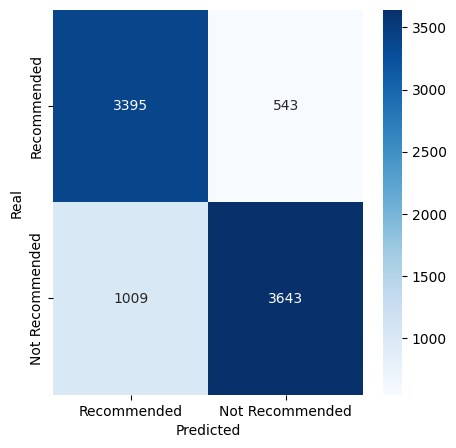

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = result["real"].unique()
cf = confusion_matrix(result["real"], result["predicted"], labels=labels)
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cf, annot=True, cmap="Blues", fmt="d", ax=ax, xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Real")
print("")

##Explicabilidad de modelos

### Feature importance

In [48]:
# Getting token family for each lemma for better understanding
raw_tokens_list = " ".join(df["Comments"]).split(" ")
lemma_family = {}
for token in raw_tokens_list:
  token = token.lower()
  lemma = simplifier.stem(token)
  if lemma not in lemma_family:
    lemma_family[lemma] = set()
  lemma_family[lemma].add(token)
lemma_family

{'hardwar': {'hardware'},
 'kill': {'kill', 'killed', 'killing', 'killings', 'kills'},
 'graphic': {'graphic', 'graphical', 'graphically', 'graphics'},
 '+1': {'+1'},
 'pointstori': {'pointstory'},
 'worth': {'worth', 'worthed', 'worths'},
 'a': {'a'},
 'damn': {'damn', 'damned'},
 'pointminigam': {'pointminigames'},
 'play': {'play',
  'played',
  'playeing',
  'playes',
  'playfully',
  'playing',
  'plays'},
 'pointonlin': {'pointonline'},
 'login': {'login', 'logined', 'logins'},
 'requir': {'require',
  'required',
  'requireing',
  'requirement',
  'requirements',
  'requires',
  'requiring',
  'requirments'},
 'for': {'for'},
 'offlin': {'offline'},
 '-1': {'-1'},
 'pointmodd': {'pointmodders'},
 'that': {'that', 'thats'},
 'ruin': {'ruin', 'ruine', 'ruined', 'ruines', 'ruining', 'ruinning', 'ruins'},
 'onlin': {'onlin', 'online', 'onlines'},
 'pointban': {'pointban'},
 'legitim': {'legitimate', 'legitimately'},
 'player': {'player', 'players'},
 'becaus': {'because'},
 'they': 

In [49]:
def map_token_family(x):
  tokens = x.split(" ")
  family = []
  for token in tokens:
    local_family = lemma_family.get(token, [])
    family.append(local_family)
  return family

feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).reset_index()
feature_importances.columns = ["feature", "importance"]
feature_importances["tokens"] = feature_importances["feature"].apply(lambda x: map_token_family(x))
feature_importances = feature_importances.sort_values(by="importance", ascending=False)
feature_importances

,feature,importance,tokens
544,mod,0.142936,"[{mods, mod, modding, modded}]"
54,ban,0.064323,"[{banning, bannings, bans, banned, ban}]"
71,best,0.055267,"[{bests, best}]"
857,take,0.045391,"[{taking, takeing, take, takes}]"
752,rockstar,0.032315,"[{rockstar, rockstars, rockstare}]"
...,...,...,...
958,watch,0.000000,"[{watch, watched, watching}]"
2,abl play,0.000000,"[{able}, {playeing, playes, playing, playfully..."
13,addit,0.000000,"[{additional, addition, additions, additionally}]"
6,act,0.000000,"[{acting, acts, act, acted}]"


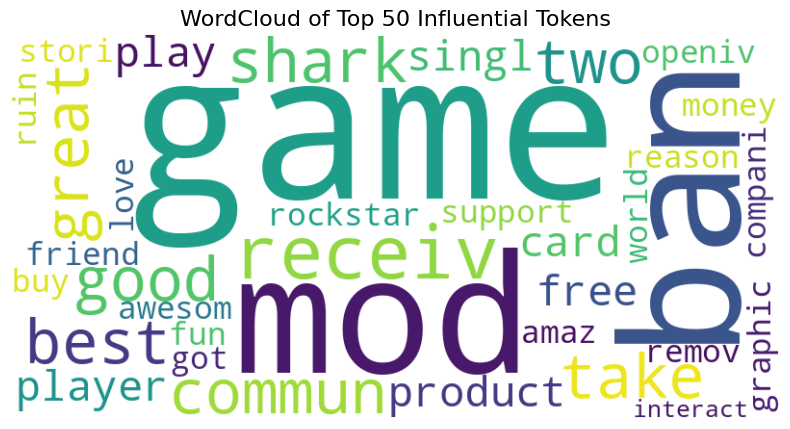

In [50]:
top_k = 50
text = " ".join(feature_importances['feature'][:top_k])

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot it
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title(f"WordCloud of Top {top_k} Influential Tokens", fontsize=16)
plt.show()

In [51]:
# Understanding %Recommended per token
token_recommended = {}
support = {}
for token in feature_importances["feature"]:
  samples_with_token = df[df["Token String"].str.contains(token)]
  recommended_samples = samples_with_token[samples_with_token["Title"] == "Recommended"]
  token_recommended[token] = len(recommended_samples) / len(samples_with_token)
  support[token] = len(samples_with_token)
feature_importances["recommended_percentage"] = feature_importances["feature"].apply(lambda x: token_recommended.get(x, None))
feature_importances["support"] = feature_importances["feature"].apply(lambda x: support.get(x, None))
feature_importances

,feature,importance,tokens,recommended_percentage,support
544,mod,0.142936,"[{mods, mod, modding, modded}]",0.212193,13549
54,ban,0.064323,"[{banning, bannings, bans, banned, ban}]",0.163688,5596
71,best,0.055267,"[{bests, best}]",0.816647,3316
857,take,0.045391,"[{taking, takeing, take, takes}]",0.087056,4388
752,rockstar,0.032315,"[{rockstar, rockstars, rockstare}]",0.243916,7027
...,...,...,...,...,...
958,watch,0.000000,"[{watch, watched, watching}]",0.573077,260
2,abl play,0.000000,"[{able}, {playeing, playes, playing, playfully...",0.262887,194
13,addit,0.000000,"[{additional, addition, additions, additionally}]",0.409722,144
6,act,0.000000,"[{acting, acts, act, acted}]",0.288636,5623


###SHAP

Influencias con SHAP usando muestra de 2000 samples

In [109]:
X_test_shap = X_test.sample(2000)
X_test_shap

,abil,abl,abl play,absolut,access,account,act,action,activ,actual,...,wtf,xbox,xd,ye,yeah,year,year ago,year old,you,your
58042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
61370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.63734,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
29262,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115400,0.174289
9457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
58484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.324509,0.000000
64281,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
13318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
18575,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.137368,0.000000


In [110]:
# Compute explanations
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_shap)

In [117]:
shap_class1 = shap_values.values[:, :, 1]
shap_df = pd.DataFrame(shap_class1, columns=X_test.columns)
shap_df

,abil,abl,abl play,absolut,access,account,act,action,activ,actual,...,wtf,xbox,xd,ye,yeah,year,year ago,year old,you,your
0,2.083122e-06,-0.000007,0.0,-0.000002,0.0,0.000275,0.0,0.000005,-0.000004,-0.000011,...,-0.000002,-0.000006,-0.000003,-0.000007,-9.572553e-07,-0.000013,6.479680e-07,1.026804e-05,-0.000020,6.085243e-07
1,1.120008e-06,-0.000003,0.0,-0.000005,0.0,0.000291,0.0,0.000004,0.000361,-0.000010,...,-0.000002,-0.000006,-0.000003,-0.000009,-8.540686e-07,-0.000012,6.479680e-07,1.520121e-06,0.000005,6.085243e-07
2,6.313200e-07,-0.000003,0.0,-0.000003,0.0,0.000219,0.0,0.000004,-0.000004,-0.000113,...,-0.000002,-0.000022,-0.000003,-0.000007,-7.318798e-07,-0.000016,6.479680e-07,1.368236e-06,-0.000169,3.995850e-07
3,2.083122e-06,-0.000081,0.0,-0.000001,0.0,0.000141,0.0,0.000004,-0.000005,-0.000012,...,-0.000029,-0.000024,-0.000002,-0.000039,-4.674457e-07,-0.000046,2.048686e-06,4.863737e-07,0.000037,6.091412e-07
4,1.120008e-06,-0.000003,0.0,-0.000004,0.0,0.000256,0.0,0.000004,-0.000005,-0.000011,...,-0.000002,-0.000006,-0.000003,-0.000006,-1.098738e-06,-0.000013,6.479680e-07,1.460289e-06,0.000004,6.085243e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9.338873e-07,-0.000003,0.0,-0.000031,0.0,0.000128,0.0,0.000004,-0.000007,-0.000229,...,-0.000003,-0.000041,-0.000014,-0.000068,-1.315118e-07,-0.000104,5.870846e-07,5.357499e-07,-0.001309,6.091412e-07
1996,9.461732e-07,0.000039,0.0,0.000005,0.0,0.000215,0.0,0.000004,-0.000003,0.000019,...,-0.000002,-0.000009,-0.000003,0.000014,4.254925e-07,0.000017,4.552095e-07,1.639476e-05,-0.000053,6.085243e-07
1997,2.083122e-06,-0.000004,0.0,-0.000003,0.0,0.000248,0.0,0.000004,-0.000008,-0.000012,...,-0.000003,-0.000007,-0.000003,-0.000011,-1.856973e-07,-0.000015,6.479680e-07,7.733863e-07,0.000005,6.091412e-07
1998,2.083122e-06,-0.000004,0.0,-0.000031,0.0,0.000093,0.0,0.000004,-0.000005,-0.000019,...,-0.000003,-0.000015,-0.000003,-0.000011,6.838898e-08,-0.000009,2.984610e-07,6.237939e-06,-0.000755,6.091412e-07


In [118]:
import numpy as np
import matplotlib.pyplot as plt

mean_abs_shap = np.abs(shap_class1).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_test_shap.columns,
    "importance": mean_abs_shap
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
544,mod,0.049301
54,ban,0.023593
71,best,0.017891
752,rockstar,0.015085
857,take,0.014749
273,game,0.010913
560,money,0.009636
613,openiv,0.009314
342,good,0.009171
860,take two,0.008150


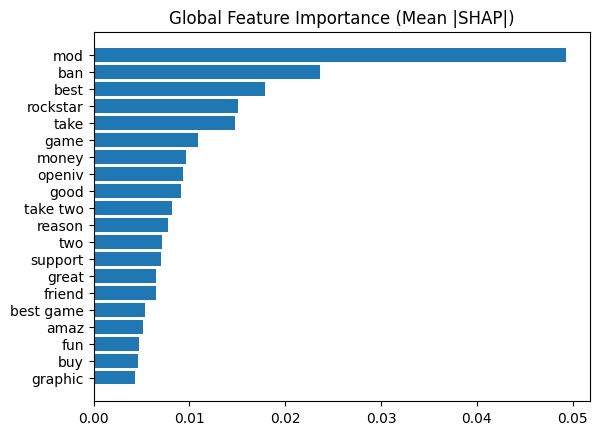

In [119]:
top20 = importance_df.head(20)

plt.figure()
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()
plt.title("Global Feature Importance (Mean |SHAP|)")
plt.show()

### Explicación global

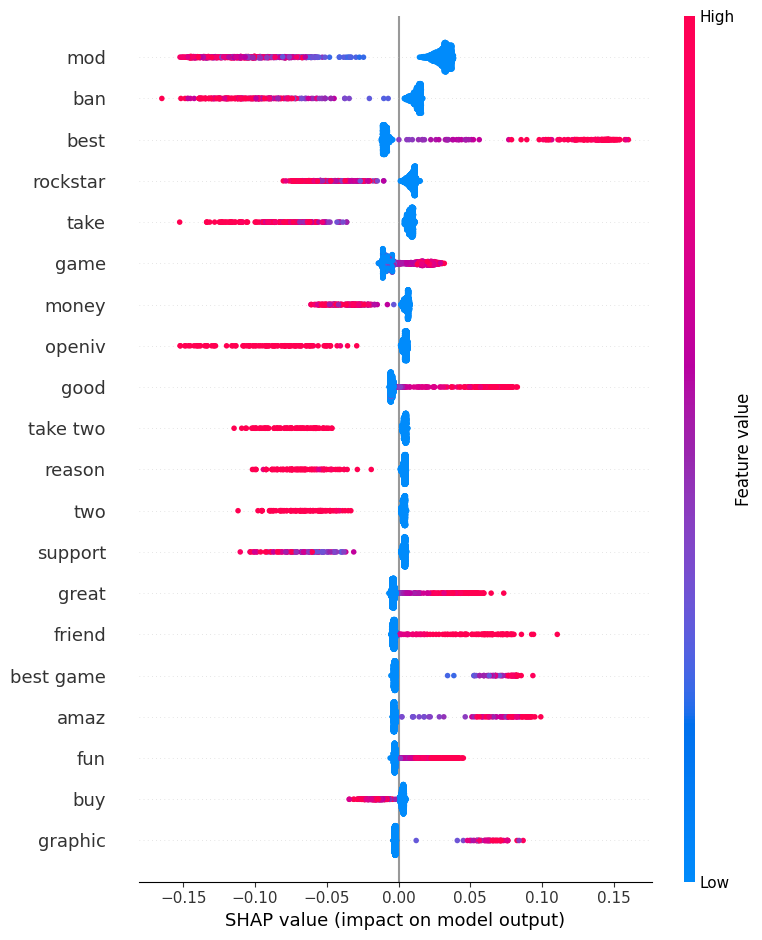

In [120]:
shap.summary_plot(
    shap_class1,
    X_test_shap,
    max_display=20
)

### Explicación local

In [115]:
print("Base model prob:", model.predict_proba(X_test_shap)[0, 1])

Base model prob: 0.4851898885936792


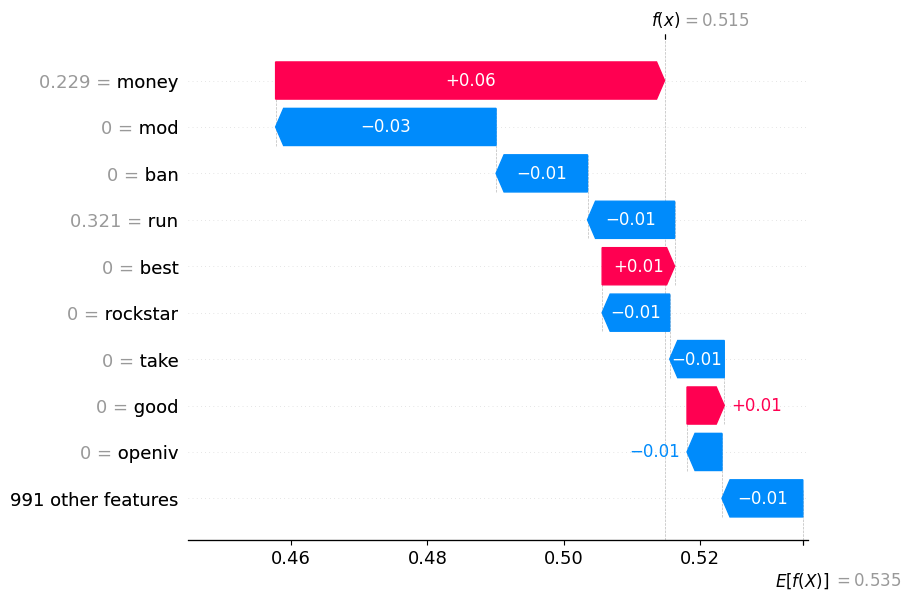

In [116]:
i = 0  # fila de estudio
shap.plots.waterfall(shap_values[i, :, 0])